# 02 — Fatorização matricial — SVD/FunkSVD
**Laboratório de Estatística Aplicada — 2026/2 | Victor Coscrato**  
**Isabella Viana Bambirra**

Notebook independente, com leitura dos dados e funções compartilhadas. Metadados entram apenas na apresentação dos títulos.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from projeto import *
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})
ratings, users, items = load_data()
display(versions())
kind = 'SVD'

{'python': '3.12.14',
 'numpy': '1.26.4',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'scikit-learn': '1.9.1',
 'scikit-surprise': '1.1.5',
 'nbformat': '5.11.1',
 'nbclient': '0.11.0',
 'ipykernel': '7.4.0'}

## 1. Como o modelo aprende
Na aproximação $R\approx UV^T$, cada usuário e filme recebe um vetor curto de fatores latentes. A semelhança entre esses vetores ajuda a estimar notas desconhecidas. O modelo inclui média global e vieses:

$$\hat r_{ui}=\mu+b_u+b_i+U_u^TV_i.$$

$\mu$ é a média do treino; $b_u$ captura tendência de um usuário dar notas maiores ou menores; $b_i$ captura tendência de um filme receber notas maiores ou menores. O produto dos vetores representa a interação que esses termos gerais não explicam.

A `SVD` da Surprise aprende com **descida do gradiente estocástico** sobre erros quadráticos de avaliações observadas, somados a uma penalização de regularização. Não executa uma SVD algébrica de matriz completada com zeros. Está relacionada ao FunkSVD dos slides, com implementação específica de vieses e SGD.

Número de fatores controla a dimensão; regularização contém ajustes excessivos; épocas definem passagens pelas notas; taxa de aprendizagem controla o tamanho de cada atualização. Fixamos a semente das inicializações. Fatores não recebem automaticamente significado de gênero; escores são estimativas de estrelas, não probabilidades de gostar.

A grade mantém taxa 0,005, testa 50/100 fatores, 20/30 épocas e regularização 0,02/0,08 em **três combinações predefinidas**, sem expansão após olhar o teste. Para usuários ou itens desconhecidos, a Surprise remove os respectivos termos não aprendidos: preserva média e viés conhecido; se ambos forem desconhecidos, usa a média global. Previsões são limitadas a [1,5].

### Função de perda regularizada
O slide soma os erros apenas no conjunto de notas observadas $\mathcal{K}$ e penaliza o tamanho dos fatores e dos vieses:

$$\mathcal{L}=\sum_{(u,i)\in\mathcal{K}}(r_{ui}-\hat r_{ui})^2+\lambda\left[\sum_u(\|U_u\|^2+b_u^2)+\sum_i(\|V_i\|^2+b_i^2)\right].$$

O primeiro termo pede previsões próximas das notas de treino; o segundo contém parâmetros excessivos. Notas ausentes não entram no erro. A implementação da Surprise aplica atualizações regularizadas a cada avaliação observada. Isso segue a lógica de FunkSVD, mas não torna idênticos os valores numéricos de regularização de implementações diferentes: a frequência das atualizações também depende da atividade de usuários e filmes. Neste projeto, `reg_all` usa o mesmo coeficiente nos fatores e nos vieses.


In [2]:
display(pd.DataFrame(CONFIGS[kind]).rename_axis('configuração'))
print(manual_checks())

,n_factors,n_epochs,lr_all,reg_all
configuração,,,,
0,50,20,0.005,0.02
1,50,30,0.005,0.08
2,100,30,0.005,0.08


RMSE manual = √2,5; Precisão@10 manual = 2/10; cold start conferido.


## Protocolo comum: prever notas e recomendar listas
Usamos **5 folds externos** de avaliações, embaralhados com semente 2026: 80 mil notas no treino e 20 mil no teste. Os mesmos índices são gravados em `data/splits/`. Todos os modelos recebem exatamente esses conjuntos. A divisão aleatória mede recuperação de avaliações ocultadas de usuários existentes; não simula integralmente recomendar filmes futuros.

O ajuste usa uma única divisão interna 80/20 dentro de cada treino externo, semente 2026 + fold. Cada algoritmo testa somente três configurações. Selecionamos o **menor RMSE interno**, com desempate pela ordem da grade. Portanto, o ajuste não foi otimizado para Precisão@10. O teste externo nunca escolhe parâmetros. A configuração inicial também é avaliada, mas as conclusões usam a ajustada.

**RMSE**: $\sqrt{\frac{1}{n}\sum_{(u,i)\in teste}(r_{ui}-\hat r_{ui})^2}$. Penaliza mais erros grandes e está na escala das notas. O baseline prevê a média global do treino; contagens de popularidade não são notas.

**Precisão@10**: $|Top10_u\cap Relevantes_u|/10$, com nota real **≥ 4 no teste** como decisão operacional. Usuário elegível precisa de histórico no treino, pelo menos dez filmes candidatos e pelo menos um relevante elegível. Candidatos são todos os filmes presentes no treino, exceto os avaliados por aquela pessoa no treino. Empates de escores são resolvidos pelo menor ID. Nenhum corte de nota prevista encurta a lista.

Os três métodos usam os mesmos candidatos e usuários. A popularidade ordena contagens de treino. Filmes sem avaliação no teste não são acertos, embora sua relevância seja desconhecida: esta é uma avaliação offline incompleta e condicionada às preferências observadas. Não é uma estimativa sem viés da precisão em uso real: a ausência de notas reduz os acertos observáveis, mas a seleção dos filmes avaliados e dos usuários elegíveis pode favorecer alguns métodos. Exclusões por usuário e motivo são salvas. RMSE inclui todo o teste, inclusive casos de filme desconhecido; Precisão@10 exclui filmes fora do catálogo de treino.

Médias e desvios-padrão amostrais resumem os cinco folds. Esses folds compartilham treinos; diferenças médias e barras de desvio não estabelecem superioridade estatística.

In [3]:
baseline_metrics = evaluate('Baselines',ratings)
display(baseline_metrics)

Baselines fold 1


Baselines fold 2


Baselines fold 3


Baselines fold 4


Baselines fold 5


,fold,model,variant,rmse,precision10,n_users,fit_seconds,evaluation_seconds,fallback_test,fallback_candidates,unknown_users,unknown_items,params
0,1,Média global,principal,1.120205,NaN,0,0.000394,0.006412,0.0,NaN,0,41,null
1,1,Popularidade,principal,NaN,0.131432,929,0.001148,0.298051,NaN,0.0,0,41,null
2,2,Média global,principal,1.117735,NaN,0,0.000416,0.002757,0.0,NaN,0,38,null
3,2,Popularidade,principal,NaN,0.137946,925,0.000569,0.296549,NaN,0.0,0,38,null
4,3,Média global,principal,1.129373,NaN,0,0.000418,0.004242,0.0,NaN,0,34,null
5,3,Popularidade,principal,NaN,0.131270,921,0.001178,0.346798,NaN,0.0,0,34,null
6,4,Média global,principal,1.124986,NaN,0,0.000443,0.004335,0.0,NaN,0,31,null
7,4,Popularidade,principal,NaN,0.136559,930,0.001067,0.324186,NaN,0.0,0,31,null
8,5,Média global,principal,1.135999,NaN,0,0.000407,0.004234,0.0,NaN,0,40,null
9,5,Popularidade,principal,NaN,0.129036,923,0.001056,0.303990,NaN,0.0,0,40,null


Os dois referenciais cumprem tarefas diferentes. A média global ignora diferenças entre usuários e filmes, mas dá uma escala de erro útil. A popularidade também não personaliza os escores, embora a exclusão de filmes conhecidos varie por pessoa. Sua capacidade de recuperar filmes relevantes será comparada à dos modelos.

In [4]:
metrics = evaluate(kind,ratings)
display(metrics)

SVD fold 1


SVD fold 2


SVD fold 3


SVD fold 4


SVD fold 5


,fold,model,variant,rmse,precision10,n_users,fit_seconds,evaluation_seconds,fallback_test,fallback_candidates,unknown_users,unknown_items,params
0,1,SVD,inicial,0.936137,0.071475,929,0.632570,0.454418,0.0,0.0,0,41,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0...."
1,1,SVD,ajustado,0.924057,0.067922,929,1.143414,0.555993,0.0,0.0,0,41,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0..."
2,2,SVD,inicial,0.930705,0.072216,925,0.648103,0.463312,0.0,0.0,0,38,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0...."
3,2,SVD,ajustado,0.918673,0.073081,925,1.166901,0.463171,0.0,0.0,0,38,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0..."
4,3,SVD,inicial,0.929422,0.073941,921,0.615029,0.588087,0.0,0.0,0,34,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0...."
5,3,SVD,ajustado,0.920589,0.066775,921,1.295335,0.502567,0.0,0.0,0,34,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0..."
6,4,SVD,inicial,0.928940,0.079570,930,0.729226,0.479748,0.0,0.0,0,31,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0...."
7,4,SVD,ajustado,0.916307,0.075699,930,1.287852,0.679324,0.0,0.0,0,31,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0..."
8,5,SVD,inicial,0.944044,0.074540,923,0.591329,0.481928,0.0,0.0,0,40,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0...."
9,5,SVD,ajustado,0.931971,0.069772,923,1.121377,0.583642,0.0,0.0,0,40,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0..."


## 2. Ajuste interno e resultados externos
A tabela seguinte identifica qual configuração venceu dentro de cada treino. O RMSE interno seleciona; o externo avalia. Tempos de treino excluem a busca, cujo custo está na tabela de ajuste. Avaliação inclui notas, candidatos, ordenação e verificações do processamento em lote. Medidas de tempo variam entre máquinas.

In [5]:
tuning = pd.read_csv(TABLES/f'{kind}_tuning.csv')
display(tuning)
display(tuning.loc[tuning.groupby('fold').inner_rmse.idxmin()])
summary = metrics.groupby('variant').agg(rmse_mean=('rmse','mean'),rmse_sd=('rmse','std'),precision10_mean=('precision10','mean'),precision10_sd=('precision10','std'))
display(save(summary.reset_index(),kind+'_variant_summary'))

,fold,model,configuration,params,inner_rmse,seconds
0,1,SVD,0,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0....",0.943409,0.614942
1,1,SVD,1,"{""n_factors"": 50, ""n_epochs"": 30, ""lr_all"": 0....",0.935915,0.722882
2,1,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.934995,0.943147
3,2,SVD,0,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0....",0.946098,0.526590
4,2,SVD,1,"{""n_factors"": 50, ""n_epochs"": 30, ""lr_all"": 0....",0.939163,0.674712
5,2,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.937551,1.041181
6,3,SVD,0,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0....",0.944149,0.646122
7,3,SVD,1,"{""n_factors"": 50, ""n_epochs"": 30, ""lr_all"": 0....",0.936452,0.752325
8,3,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.935934,0.949955
9,4,SVD,0,"{""n_factors"": 50, ""n_epochs"": 20, ""lr_all"": 0....",0.940928,0.602353


,fold,model,configuration,params,inner_rmse,seconds
2,1,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.934995,0.943147
5,2,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.937551,1.041181
8,3,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.935934,0.949955
11,4,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.926530,0.986773
14,5,SVD,2,"{""n_factors"": 100, ""n_epochs"": 30, ""lr_all"": 0...",0.934870,1.129042


,variant,rmse_mean,rmse_sd,precision10_mean,precision10_sd
0,ajustado,0.922319,0.006095,0.070650,0.003695
1,inicial,0.933850,0.006379,0.074348,0.003173


In [6]:
adjusted = summary.loc['ajustado']; initial = summary.loc['inicial']
display(Markdown(f"A configuração inicial teve RMSE médio **{initial.rmse_mean:.4f}**, e o procedimento ajustado teve **{adjusted.rmse_mean:.4f}**. A Precisão@10 ajustada foi **{adjusted.precision10_mean:.4f}** (desvio entre folds **{adjusted.precision10_sd:.4f}**). Em média, isso equivale a **{10*adjusted.precision10_mean:.3f}** acertos observados por lista de dez. O ajuste por RMSE não garante avanço na precisão das listas."))

A configuração inicial teve RMSE médio **0.9338**, e o procedimento ajustado teve **0.9223**. A Precisão@10 ajustada foi **0.0707** (desvio entre folds **0.0037**). Em média, isso equivale a **0.707** acertos observados por lista de dez. O ajuste por RMSE não garante avanço na precisão das listas.

### Leitura frente aos baselines
O SVD ajustado teve RMSE **0,9223**, contra **1,1257** da média global: sua previsão de notas foi melhor em todos os cinco folds. Na recuperação de listas, sua Precisão@10 foi **0,0707**, abaixo de **0,1332** da popularidade. Portanto, a personalização do SVD não superou esse referencial no protocolo principal.

A configuração inicial teve RMSE **0,9338** e Precisão@10 **0,0743**. A busca interna por RMSE levou a 100 fatores, 30 épocas e regularização 0,08 nos cinco folds; o erro caiu, enquanto a recuperação das listas diminuiu. Esse resultado deve ser mantido, pois a seleção foi definida antes da avaliação externa. Ele evidencia a diferença entre prever estrelas e escolher dez filmes.

## 3. Cobertura e exclusões
Verificamos casos que não podem entrar no ranking principal. Um filme que só apareceu no teste não pertence ao catálogo de treino; sua nota continua na avaliação RMSE, usando a regra documentada para cold start. Na tabela, `unknown_items` conta avaliações de teste com item desconhecido, e não quantidade de IDs distintos.

In [7]:
eligibility = pd.read_csv(TABLES/f'{kind}_eligibility.csv')
display(eligibility[eligibility.variant=='ajustado'].groupby(['fold','reason']).size().rename('usuarios').reset_index())
display(metrics[metrics.variant=='ajustado'][['fold','n_users','unknown_users','unknown_items','fallback_test','fallback_candidates']])

,fold,reason,usuarios
0,1,incluido,929
1,1,sem_relevante_elegivel,14
2,2,incluido,925
3,2,sem_relevante_elegivel,18
4,3,incluido,921
5,3,sem_relevante_elegivel,22
6,4,incluido,930
7,4,sem_relevante_elegivel,13
8,5,incluido,923
9,5,sem_relevante_elegivel,20


,fold,n_users,unknown_users,unknown_items,fallback_test,fallback_candidates
1,1,929,0,41,0.0,0.0
3,2,925,0,38,0.0,0.0
5,3,921,0,34,0.0,0.0
7,4,930,0,31,0.0,0.0
9,5,923,0,40,0.0,0.0


## 4. Onde as previsões erram
Agrupamos erros externos por nota real e por quantidade de histórico de treino. Cada avaliação participa de um único teste externo. Essas análises descrevem heterogeneidade do erro; não alteram o modelo e não selecionam configurações.

,rating,n,mse,mean_prediction,rmse
0,1,6110,3.550306,2.753217,1.884226
1,2,11370,1.476247,3.085742,1.215009
2,3,27145,0.372017,3.367800,0.609932
3,4,34174,0.302685,3.684004,0.550168
4,5,21201,1.233463,3.987072,1.110614


,history_group,n,mse,rmse
0,até 30,8059,0.997908,0.998953
1,31 a 100,26169,0.895354,0.946232
2,mais de 100,65772,0.814900,0.902718


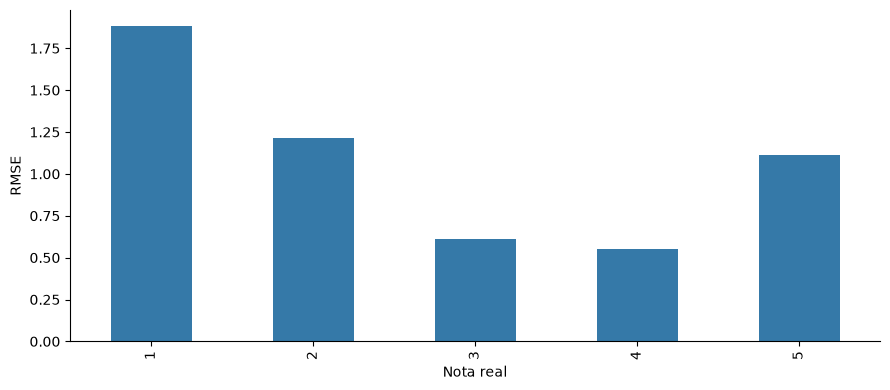

O maior RMSE por nota real ocorre na nota **1**, com **1.884**. O agrupamento por histórico usa cortes fixos de 30 e 100 notas no treino. As diferenças são descritivas: usuários ativos também podem ter preferências diferentes, e não podemos atribuir causalmente o erro à quantidade de histórico.

In [8]:
predictions = pd.read_csv(TABLES / f'{kind}_predictions.csv')
predictions = predictions[predictions.variant=='ajustado'].copy()
predictions['squared_error'] = (predictions.rating-predictions.prediction)**2
by_rating = predictions.groupby('rating').agg(n=('rating','size'),mse=('squared_error','mean'),mean_prediction=('prediction','mean'))
by_rating['rmse'] = np.sqrt(by_rating.mse)
display(save(by_rating.reset_index(),kind+'_error_by_rating'))
predictions['history_group'] = pd.cut(predictions.n_history,[-1,30,100,np.inf],labels=['até 30','31 a 100','mais de 100'])
by_history = predictions.groupby('history_group',observed=True).agg(n=('rating','size'),mse=('squared_error','mean'))
by_history['rmse'] = np.sqrt(by_history.mse)
display(save(by_history.reset_index(),kind+'_error_by_history'))
by_rating.rmse.plot.bar(color='#3579a8'); plt.ylabel('RMSE'); plt.xlabel('Nota real')
plt.tight_layout(); plt.savefig(FIGURES/f'{kind}_errors.png',dpi=150); plt.show()
worst = by_rating.rmse.idxmax()
display(Markdown(f"O maior RMSE por nota real ocorre na nota **{worst}**, com **{by_rating.loc[worst,'rmse']:.3f}**. O agrupamento por histórico usa cortes fixos de 30 e 100 notas no treino. As diferenças são descritivas: usuários ativos também podem ter preferências diferentes, e não podemos atribuir causalmente o erro à quantidade de histórico."))

## 5. Recomendações para os mesmos perfis de atividade
Escolhemos, **no treino do fold 1**, usuários mais próximos dos quantis 10%, 50% e 90% do número de notas; desempate por menor ID. SVD e KNN repetem os mesmos usuários. A configuração deste exemplo é a selecionada internamente no fold 1 e treinada apenas nas 80 mil notas daquele treino.

As tabelas mostram dez recomendações e um recorte de dez notas do histórico, ordenadas por nota e ID; o histórico completo fica salvo. Estes são **exemplos do modelo de avaliação**, não um modelo final treinado em toda a base. Os títulos ajudam a ler as listas, mas não entram na previsão. Escores altos não provam relevância de filmes sem nota observada.

In [9]:
recommendations, history = examples(kind,ratings,items)
display(recommendations)
for activity, g in history.groupby('activity',sort=False):
    print(activity, '— usuário', g.user_id.iloc[0], '— histórico completo:',len(g))
    display(g.sort_values(['rating','item_id'],ascending=[False,True])[['item_id','title','rating']].head(10))
print('Históricos completos salvos em outputs/tables/'+kind+'_example_history.csv')

,activity,user_id,n_history,rank,item_id,score,title
0,baixa,9,19,1,408,4.922896,"Close Shave, A (1995)"
1,baixa,9,19,2,1449,4.872884,Pather Panchali (1955)
2,baixa,9,19,3,318,4.815766,Schindler's List (1993)
3,baixa,9,19,4,64,4.778819,"Shawshank Redemption, The (1994)"
4,baixa,9,19,5,513,4.771401,"Third Man, The (1949)"
5,baixa,9,19,6,169,4.731105,"Wrong Trousers, The (1993)"
6,baixa,9,19,7,479,4.718390,Vertigo (1958)
7,baixa,9,19,8,251,4.705311,Shall We Dance? (1996)
8,baixa,9,19,9,661,4.705132,High Noon (1952)
9,baixa,9,19,10,427,4.700772,To Kill a Mockingbird (1962)


baixa — usuário 9 — histórico completo: 19


,item_id,title,rating
4,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,5
16,50,Star Wars (1977),5
15,201,Evil Dead II (1987),5
3,286,"English Patient, The (1996)",5
13,371,"Bridges of Madison County, The (1995)",5
18,385,True Lies (1994),5
11,483,Casablanca (1942),5
2,487,Roman Holiday (1953),5
0,691,Dark City (1998),5
17,7,Twelve Monkeys (1995),4


intermediária — usuário 206 — histórico completo: 52


,item_id,title,rating
64,272,Good Will Hunting (1997),5
27,288,Scream (1996),5
19,302,L.A. Confidential (1997),5
65,310,"Rainmaker, The (1997)",5
46,313,Titanic (1997),5
41,315,Apt Pupil (1998),5
40,895,Scream 2 (1997),5
30,258,Contact (1997),4
47,269,"Full Monty, The (1997)",4
26,333,"Game, The (1997)",4


alta — usuário 932 — histórico completo: 198


,item_id,title,rating
211,9,Dead Man Walking (1995),5
229,45,Eat Drink Man Woman (1994),5
249,89,Blade Runner (1982),5
121,98,"Silence of the Lambs, The (1991)",5
170,100,Fargo (1996),5
257,119,Maya Lin: A Strong Clear Vision (1994),5
71,135,2001: A Space Odyssey (1968),5
223,136,Mr. Smith Goes to Washington (1939),5
110,154,Monty Python's Life of Brian (1979),5
247,168,Monty Python and the Holy Grail (1974),5


Históricos completos salvos em outputs/tables/SVD_example_history.csv


In [10]:
for activity,g in recommendations.groupby('activity',sort=False):
    display(Markdown(f"No perfil **{activity}**, o usuário **{g.user_id.iloc[0]}** tem **{g.n_history.iloc[0]}** notas no treino. A lista começa com **{g.iloc[0].title}**, escore **{g.iloc[0].score:.3f}**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística."))

No perfil **baixa**, o usuário **9** tem **19** notas no treino. A lista começa com **Close Shave, A (1995)**, escore **4.923**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

No perfil **intermediária**, o usuário **206** tem **52** notas no treino. A lista começa com **Schindler's List (1993)**, escore **3.638**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

No perfil **alta**, o usuário **932** tem **198** notas no treino. A lista começa com **Close Shave, A (1995)**, escore **4.631**. Esses escores permitem ordenar candidatos; seu significado é de nota prevista, sem interpretação probabilística.

## Continuidade
O próximo notebook avalia o KNN com os mesmos folds e candidatos e reúne a comparação final. Os resultados deste notebook ficam em CSV, com erros externos e listas por usuário, permitindo auditar e reapresentar a análise sem refazer a seleção de parâmetros.

Referência técnica: [Surprise SVD](https://surprise.readthedocs.io/en/stable/matrix_factorization.html).